# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [30]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [31]:
print("Số dòng: ", df.shape[0], "| Số cột: ", df.shape[1])
print("Tên các cột: ", df.columns.tolist())
print()
df.info()


Số dòng:  541909 | Số cột:  8
Tên các cột:  ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


## A.2. Missing values & Duplicate data

In [32]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "Không có cột thiếu dữ liệu.")
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values:
Description      1454
CustomerID     135080
dtype: int64

Duplicate rows: 5268


## A.3. Invalid values

In [33]:
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())
print("\nCountry rỗng:", df['Country'].isna().sum())

Quantity <= 0: 10624
UnitPrice <= 0: 2517

Country rỗng: 0


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [34]:
df_goc = df.copy()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df['Sales'] = df['Quantity'] * df['UnitPrice']
print("Kích thước sau khi làm sạch:", df.shape[0])
print(df[['Quantity', 'UnitPrice', 'Sales']].head())

Kích thước sau khi làm sạch: 530104
   Quantity  UnitPrice  Sales
0         6       2.55  15.30
1         6       3.39  20.34
2         8       2.75  22.00
3         6       3.39  20.34
4         6       3.39  20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [35]:
for col in ['UnitPrice', 'Quantity', 'Sales']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"---{col}---")
    print(f"Mean= {mean_}, Median= {median_}, Mode= {mode_}")

---UnitPrice---
Mean= 3.9076252471213193, Median= 2.08, Mode= 1.25
---Quantity---
Mean= 10.542037034242338, Median= 3.0, Mode= 1
---Sales---
Mean= 20.121871451639677, Median= 9.9, Mode= 15.0


## Group 2 — Dispersion

In [36]:
for col in ['UnitPrice', 'Quantity', 'Sales']:
    s = df[col]
    range_ = s.max() - s.min()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3-q1
    std_ = s.std()
    cv = std_/s.mean()*100
    print(f"---{col}---")
    print(f"range= {range_}, iqr= {iqr}, std= {std_}, cv= {cv}")

---UnitPrice---
range= 13541.329, iqr= 2.88, std= 35.915681104255434, cv= 919.1178486400123
---Quantity---
range= 80994, iqr= 9.0, std= 155.52412351063626, cv= 1475.2758219826712
---Sales---
range= 168469.59900000002, iqr= 13.950000000000003, std= 270.35674321840673, cv= 1343.596413823507


## Group 3 — Location and Shape

---UnitPrice---
Skew= 206.08697179737123, Kurtosis= 62482.55335737786
---Quantity---
Skew= 471.72638151377913, Kurtosis= 236460.11248175093
---Sales---
Skew= 506.70457814887453, Kurtosis= 297648.853558276


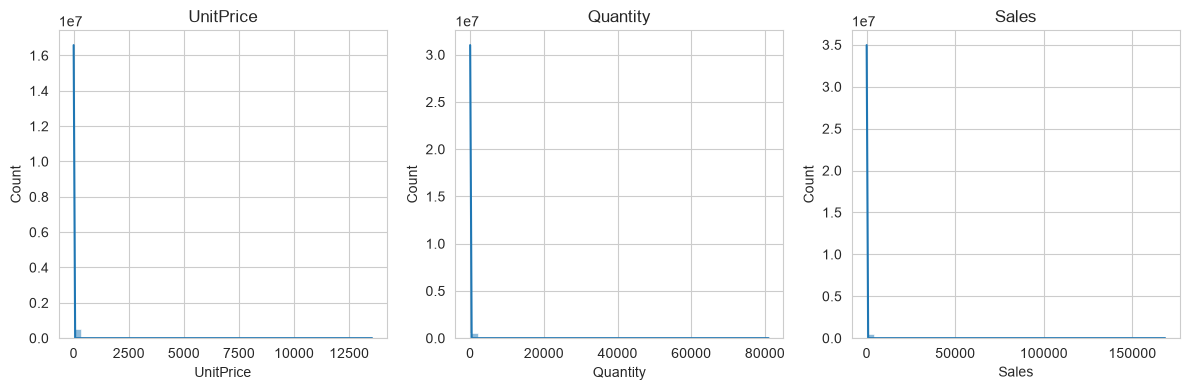

Nhận xét: Ba biến đều phân phối lệch phải mạnh, cho thấy phần lớn dữ liệu tập trung ở các giá trị thấp trong khi một số quan sát có giá trị rất cao. Kurtosis lớn cũng cho thấy dữ liệu có đuôi phân phối nặng và khả năng xuất hiện các giá trị cực đoan.


In [37]:
for col in ['UnitPrice', 'Quantity', 'Sales']:
    s = df[col]
    skew_, kurtosis_ = stats.skew(s), stats.kurtosis(s)
    print(f"---{col}---")
    print(f"Skew= {skew_}, Kurtosis= {kurtosis_}")
fig, axes = plt.subplots(1,3,figsize=(12,4))
sns.histplot(df['UnitPrice'], bins=40, kde=True, ax=axes[0]); axes[0].set_title('UnitPrice')
sns.histplot(df['Quantity'], bins=40, kde=True, ax=axes[1]); axes[1].set_title('Quantity')
sns.histplot(df['Sales'], bins=40, kde=True, ax=axes[2]); axes[2].set_title('Sales')
plt.tight_layout(); plt.show()
print("Nhận xét: Ba biến đều phân phối lệch phải mạnh, cho thấy phần lớn dữ liệu tập trung ở các giá trị thấp trong khi một số quan sát có giá trị rất cao. Kurtosis lớn cũng cho thấy dữ liệu có đuôi phân phối nặng và khả năng xuất hiện các giá trị cực đoan.")


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [38]:
doanh_thu_quoc_gia = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
print(f"Country có doanh thu cao nhất: {doanh_thu_quoc_gia.idxmax()}, Doanh thu = {doanh_thu_quoc_gia.max()}")
print(doanh_thu_quoc_gia)
tong_doanh_thu = df['Sales'].sum()
phan_tram = doanh_thu_quoc_gia.max() / tong_doanh_thu * 100
print(f"Chiếm {phan_tram.round(2)} % tổng doanh thu")

Country có doanh thu cao nhất: United Kingdom, Doanh thu = 9025222.084
Country
United Kingdom          9025222.084
Netherlands              285446.340
EIRE                     283453.960
Germany                  228867.140
France                   209715.110
Australia                138521.310
Spain                     61577.110
Switzerland               57089.900
Belgium                   41196.340
Sweden                    38378.330
Japan                     37416.370
Norway                    36165.440
Portugal                  33747.100
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20450.440
Denmark                   18955.340
Italy                     17483.240
Hong Kong                 15691.800
Cyprus                    13590.380
Austria                   10198.680
Israel                     8135.260
Poland                     7334.650
Greece                     4760.520
Unspecified                4749.790
Iceland              

## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [39]:
doanh_thu_san_pham = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)
print(f"Sản phẩm có tổng doanh thu cao nhất: {doanh_thu_san_pham.idxmax()} | Doanh thu đạt: {doanh_thu_san_pham.max()}")

Sản phẩm có tổng doanh thu cao nhất: DOTCOM POSTAGE | Doanh thu đạt: 206248.77


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

In [40]:
df['Month'] = df['InvoiceDate'].dt.month
print(df.groupby('Month')['Sales'].sum())
print("Nhận xét: Doanh thu giữa các tháng có sự chênh lệch rõ rệt, cho thấy hoạt động kinh doanh có yếu tố mùa vụ. Giai đoạn từ tháng 9 đến tháng 12 ghi nhận doanh thu cao hơn, trong đó tháng 11 đạt mức cao nhất. Ngược lại, doanh thu trong khoảng tháng 1 đến tháng 8 nhìn chung thấp hơn.")

Month
1      691364.560
2      523631.890
3      717639.360
4      537808.621
5      770536.020
6      761739.900
7      719221.191
8      759138.380
9     1058590.172
10    1154979.300
11    1509496.330
12    1462538.820
Name: Sales, dtype: float64
Nhận xét: Doanh thu giữa các tháng có sự chênh lệch rõ rệt, cho thấy hoạt động kinh doanh có yếu tố mùa vụ. Giai đoạn từ tháng 9 đến tháng 12 ghi nhận doanh thu cao hơn, trong đó tháng 11 đạt mức cao nhất. Ngược lại, doanh thu trong khoảng tháng 1 đến tháng 8 nhìn chung thấp hơn.


## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [41]:
print(df.groupby('Country')['Sales'].mean().sort_values(ascending=False))
print("Nhận xét: Giá trị doanh thu trung bình trên mỗi đơn hàng có sự chênh lệch giữa các quốc gia. Trong đó, Australia, Netherlands, Japan, Singapore và Sweden ghi nhận mức doanh thu trung bình tương đối cao, cho thấy giá trị đơn hàng tại các thị trường này nổi bật hơn so với nhiều quốc gia khác.")


Country
Netherlands             121.003111
Australia               117.192310
Japan                   116.561900
Singapore                95.852658
Sweden                   85.096075
Hong Kong                55.252817
Denmark                  49.882474
Lithuania                47.458857
Bahrain                  41.896667
Lebanon                  37.641778
EIRE                     35.925724
Brazil                   35.737500
Norway                   33.767918
Czech Republic           33.069600
Finland                  32.913985
Greece                   32.831172
Switzerland              29.038606
United Arab Emirates     27.974706
Israel                   27.577153
Channel Islands          27.340160
Austria                  25.624824
Germany                  25.317162
France                   24.945297
Spain                    24.789497
Malta                    24.335625
Canada                   24.280662
Iceland                  23.681319
Italy                    23.064960
Portugal    

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [42]:
df['ReturnQuantity'] = df['Quantity'] < 0
pc = df.groupby('Country')['ReturnQuantity'].mean() * 100
print(pc.sort_values(ascending=False))
print("Nhận xét: Không có dữ liệu trả hàng vì tất cả giá trị Quantity đều lớn hơn 0, nên tỷ lệ trả hàng ở tất cả các quốc gia đều là 0%.")

Country
Australia               0.0
Austria                 0.0
Bahrain                 0.0
Belgium                 0.0
Brazil                  0.0
Canada                  0.0
Channel Islands         0.0
Cyprus                  0.0
Czech Republic          0.0
Denmark                 0.0
EIRE                    0.0
European Community      0.0
Finland                 0.0
France                  0.0
Germany                 0.0
Greece                  0.0
Hong Kong               0.0
Iceland                 0.0
Israel                  0.0
Italy                   0.0
Japan                   0.0
Lebanon                 0.0
Lithuania               0.0
Malta                   0.0
Netherlands             0.0
Norway                  0.0
Poland                  0.0
Portugal                0.0
RSA                     0.0
Saudi Arabia            0.0
Singapore               0.0
Spain                   0.0
Sweden                  0.0
Switzerland             0.0
USA                     0.0
United Arab 

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Dữ liệu bán hàng thể hiện rõ sự phân hóa mạnh với các biến Quantity, UnitPrice và Sales đều có phân phối lệch phải và hệ số Kurtosis rất cao, phản ánh việc đa số đơn hàng có giá trị nhỏ nhưng vẫn tồn tại các giao dịch đột biến quy mô lớn.

United Kingdom đóng vai trò là thị trường trọng điểm khi chiếm áp đảo tới 84.61% tổng doanh thu của doanh nghiệp.

Dù quy mô tổng doanh thu thấp hơn, các thị trường quốc tế như Netherlands, Australia, Japan và Singapore lại sở hữu giá trị đơn hàng trung bình (AOV) vượt trội hơn hẳn so với thị trường nội địa UK

Doanh thu ghi nhận tính chu kỳ và mùa vụ rõ nét khi tăng vọt vào giai đoạn quý IV (tháng 9 đến tháng 12), trong đó đỉnh điểm rơi vào tháng 11.
